In [4]:
import cv2 as cv
import numpy as np
from skimage.feature import blob_log
from skimage.color import rgb2gray

Detected 165 blobs.


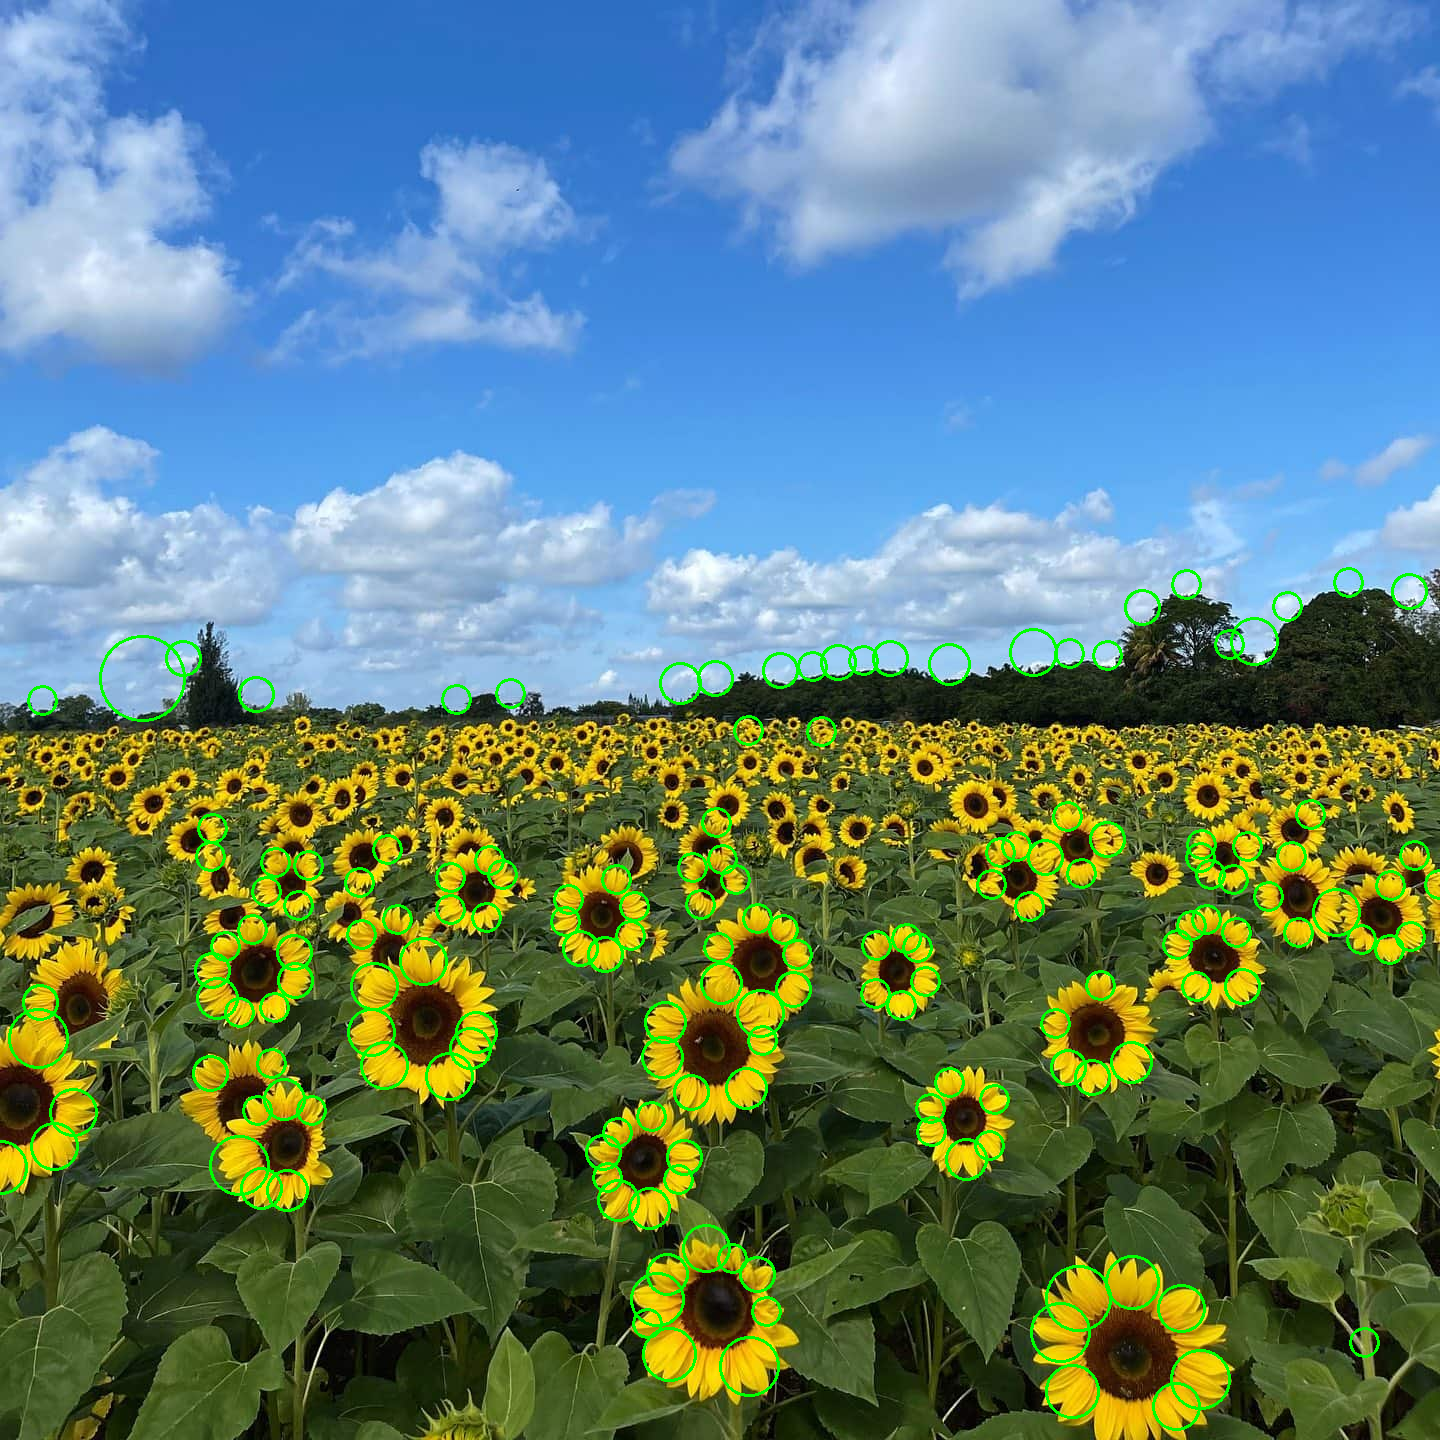

In [8]:
import cv2 as cv
import numpy as np
from skimage.color import rgb2gray
from skimage.feature import blob_log
from google.colab.patches import cv2_imshow # Import cv2_imshow

# Load the image
im_bgr = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_COLOR)

if im_bgr is None:
    print("Error: Could not load image.")
else:
    # Convert to grayscale for blob detection
    im_gray_skimage = rgb2gray(im_bgr)

    # Parameters for LoG
    min_sigma = 10
    max_sigma = 30
    num_sigma = 10
    threshold = 0.15
    overlap = 0.5


    # blobs_log will contain (y, x, sigma) for each blob
    blobs_log = blob_log(im_gray_skimage,
                         min_sigma=min_sigma,
                         max_sigma=max_sigma,
                         num_sigma=num_sigma,
                         threshold=threshold,
                         overlap=overlap)


    blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

    # Create a copy of the original BGR image to draw on
    im_display = im_bgr.copy()

    # Draw circles around the blobs
    print(f"Detected {len(blobs_log)} blobs.")
    largest_circles = []

    for blob in blobs_log:
        y, x, r = blob.astype(int) # Convert to int for drawing
        cv.circle(im_display, (x, y), r, (0, 255, 0), 2) # Green circle, 2px thick
        largest_circles.append({'x': x, 'y': y, 'radius': r})

    # Sort by radius to easily identify the largest
    largest_circles.sort(key=lambda b: b['radius'], reverse=True)

    # Display the image using cv2_imshow
    cv2_imshow(im_display) # Use cv2_imshow instead of cv.imshow()

    #save
    cv.imwrite('output_image.jpg',im_display)

#

Estimated line (a,b,d): (np.float64(-0.7184192033652615), np.float64(-0.6956104141227495), np.float64(-1.4753449080312482)) inliers: 36
RANSAC circle model (cx,cy,r): (np.float64(5.31719237030418), np.float64(3.5227748460038897), np.float64(12.511753273250772)) inliers: 26
Refined circle: (np.float64(5.196125025896037), np.float64(3.2006754538838864), np.float64(12.522064926306738))


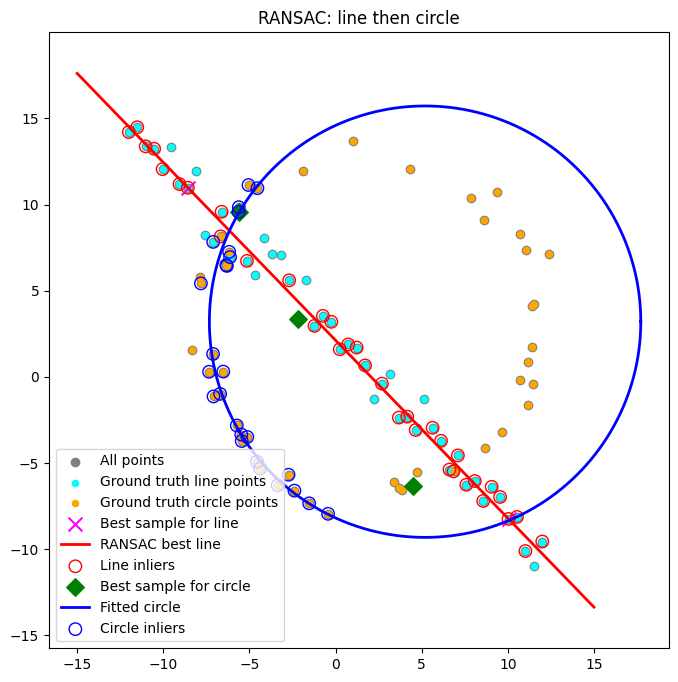


(d) What happens if we fit circle first?
If we fit a circle first (with RANSAC) the large set of line points may act as outliers and reduce chance of finding circle inliers unless thresholds and consensus sizes are tuned. It may also pick a spurious circle from combinations including line points. Generally order matters when one model dominates.


In [2]:
# Q2 - RANSAC line then circle
!pip install --quiet numpy matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
np.random.seed(0)

# Generate dataset from Listing 1 (adapted)
N = 100
half_n = N//2

r = 10
x0_gt, y0_gt = 2.0, 3.0
s = r/16.0
t = np.random.uniform(0, 2*np.pi, half_n)
n = s * np.random.randn(half_n)
x = x0_gt + (r + n)*np.cos(t)
y = y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n,1), y.reshape(half_n,1)))

s_line = 1.0
m, b = -1.0, 2.0
x_line = np.linspace(-12,12,half_n)
y_line = m*x_line + b + s_line*np.random.randn(half_n)
X_line = np.hstack((x_line.reshape(half_n,1), y_line.reshape(half_n,1)))

X = np.vstack((X_circ, X_line))

# Helper: fit line in TLS form (unit normal a,b and distance d)
def fit_line_from_two_points(p1, p2):
    # direction vector
    dx = p2[0]-p1[0]; dy = p2[1]-p1[1]
    # normal is perpendicular (normalized)
    n = np.array([dy, -dx])
    n_norm = np.linalg.norm(n)
    if n_norm == 0:
        return None
    n = n / n_norm
    d = n.dot(p1)
    return n[0], n[1], d

def point_line_distance(points, a, b, d):
    # normal (a,b) assumed unit
    return np.abs(points.dot(np.array([a,b])) - d)

# RANSAC for line
def ransac_line(points, n_iter=500, thresh=0.5, min_consensus=30):
    best = None
    best_inliers = []
    best_sample = None
    for _ in range(n_iter):
        i,j = np.random.choice(points.shape[0], 2, replace=False)
        p1, p2 = points[i], points[j]
        res = fit_line_from_two_points(p1,p2)
        if res is None: continue
        a,b,d = res
        dists = point_line_distance(points, a,b,d)
        inliers = np.where(dists < thresh)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best = (a,b,d)
            best_sample = (p1,p2)
    return best, best_inliers, best_sample

line_model, line_inliers, line_sample = ransac_line(X, n_iter=2000, thresh=0.6, min_consensus=30)
a,b,d = line_model
print("Estimated line (a,b,d):", (a,b,d), "inliers:", len(line_inliers))

# Remove line inliers and fit circle to remainder using RANSAC+optimize
remaining_idx = np.setdiff1d(np.arange(X.shape[0]), line_inliers)
X_rem = X[remaining_idx]

# Circle fit function (least squares radial error)
def circle_residual(params, pts):
    x0,y0,r = params
    rads = np.sqrt((pts[:,0]-x0)**2 + (pts[:,1]-y0)**2)
    return np.sum((rads - r)**2)

# RANSAC circle: sample 3 points -> compute circle through 3 points -> count inliers
def circle_from_3(p1,p2,p3):
    # compute circle using circumcenter formula
    A = np.array([
        [p1[0], p1[1], 1],
        [p2[0], p2[1], 1],
        [p3[0], p3[1], 1]
    ], dtype=np.float64)
    # Using linear algebra method
    def det(m): return np.linalg.det(m)
    a = np.array([ [p1[0]**2+p1[1]**2, p1[1], 1],
                   [p2[0]**2+p2[1]**2, p2[1], 1],
                   [p3[0]**2+p3[1]**2, p3[1], 1] ])
    Dx = np.linalg.det(a)
    a = np.array([ [p1[0]**2+p1[1]**2, p1[0], 1],
                   [p2[0]**2+p2[1]**2, p2[0], 1],
                   [p3[0]**2+p3[1]**2, p3[0], 1] ])
    Dy = -np.linalg.det(a)
    a = np.array([ [p1[0]**2+p1[1]**2, p1[0], p1[1]],
                   [p2[0]**2+p2[1]**2, p2[0], p2[1]],
                   [p3[0]**2+p3[1]**2, p3[0], p3[1]] ])
    D = np.linalg.det(a)
    if np.abs(D) < 1e-6:
        return None
    cx = Dx/(2*D)
    cy = Dy/(2*D)
    r = np.sqrt((p1[0]-cx)**2 + (p1[1]-cy)**2)
    return cx, cy, r

def ransac_circle(points, n_iter=2000, thresh=0.8, min_consensus=15):
    best = None
    best_inliers = []
    best_sample = None
    n = points.shape[0]
    for _ in range(n_iter):
        ids = np.random.choice(n, 3, replace=False)
        p1,p2,p3 = points[ids]
        circ = circle_from_3(p1,p2,p3)
        if circ is None: continue
        cx,cy,r = circ
        dists = np.abs(np.sqrt((points[:,0]-cx)**2 + (points[:,1]-cy)**2) - r)
        inliers = np.where(dists < thresh)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best = (cx,cy,r)
            best_sample = points[ids]
    return best, best_inliers, best_sample

circ_model, circ_inliers, circ_sample = ransac_circle(X_rem, n_iter=2000, thresh=0.8, min_consensus=15)
print("RANSAC circle model (cx,cy,r):", circ_model, "inliers:", len(circ_inliers))

# refine circle using optimize over inliers
if circ_model is not None and len(circ_inliers)>3:
    inlier_pts = X_rem[circ_inliers]
    x0_init,y0_init,r_init = circ_model
    res = minimize(lambda p: circle_residual(p, inlier_pts), x0=[x0_init,y0_init,r_init], method='Nelder-Mead')
    cx,cy,r = res.x
    print("Refined circle:", (cx,cy,r))
else:
    cx,cy,r = circ_model

# Plot everything in a single figure
plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], c='gray', label='All points')
plt.scatter(X_line[:,0], X_line[:,1], c='cyan', label='Ground truth line points', s=20)
plt.scatter(X_circ[:,0], X_circ[:,1], c='orange', label='Ground truth circle points', s=20)

# Show best sample used for line
if line_sample:
    p1,p2 = line_sample
    plt.scatter([p1[0],p2[0]],[p1[1],p2[1]], c='magenta', s=100, label='Best sample for line', marker='x')
# Plot RANSAC line
xs = np.linspace(-15,15,2)
# compute line equation from a,b,d: point x satisfies a*x + b*y = d -> y = (d - a*x)/b
if abs(b) > 1e-6:
    ys = (d - a*xs)/b
    plt.plot(xs, ys, color='red', linewidth=2, label='RANSAC best line')

# Show line inliers
plt.scatter(X[line_inliers,0], X[line_inliers,1], facecolors='none', edgecolors='red', s=80, label='Line inliers')

# Plot circle sample points (3)
if circ_sample is not None:
    plt.scatter(circ_sample[:,0], circ_sample[:,1], c='green', s=80, label='Best sample for circle', marker='D')

# Plot circle
if circ_model is not None:
    theta = np.linspace(0,2*np.pi,200)
    plt.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), color='blue', linewidth=2, label='Fitted circle')

# Circle inliers (on remainder set)
if circ_inliers is not None and len(circ_inliers)>0:
    plt.scatter(X_rem[circ_inliers,0], X_rem[circ_inliers,1], facecolors='none', edgecolors='blue', s=80, label='Circle inliers')

plt.axis('equal')
plt.legend()
plt.title('RANSAC: line then circle')
plt.show()

# (d) short answer printed:
print("\n(d) What happens if we fit circle first?")
print("If we fit a circle first (with RANSAC) the large set of line points may act as outliers and reduce"
      " chance of finding circle inliers unless thresholds and consensus sizes are tuned. It may also pick a"
      " spurious circle from combinations including line points. Generally order matters when one model dominates.")


Upload two images: (1) background/architectural image, (2) flag image to map.


Saving background.jpg to background (1).jpg
Saving flag.webp to flag.webp

Provide four destination points (clockwise or anticlockwise) within background image coordinates.
Example format: [[x0,y0],[x1,y1],[x2,y2],[x3,y3]]
Example coordinates (try these if unsure): [[500.0, 167.25], [840.0, 173.8000030517578], [960.0, 434.5], [480.0, 434.5]]


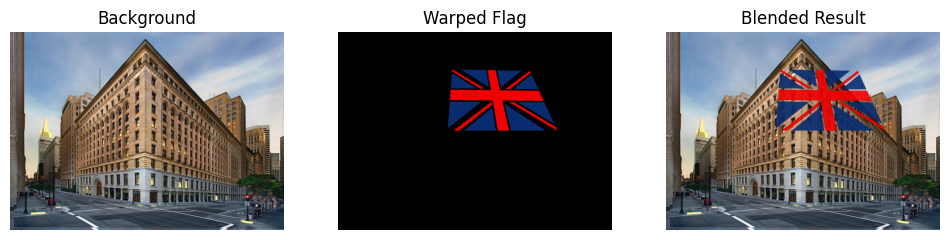

Saved: homography_blend_result.png


In [5]:
# Q3 - Homography warp (Colab cell)
!pip install --quiet opencv-python-headless matplotlib numpy

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload two images: (1) background/architectural image, (2) flag image to map.")
uploaded = files.upload()
keys = list(uploaded.keys())
if len(keys) < 2:
    raise RuntimeError("Please upload two images in the file chooser.")

bg_fn = keys[0]   # architectural
flag_fn = keys[1] # flag

bg = cv.imdecode(np.frombuffer(uploaded[bg_fn], np.uint8), cv.IMREAD_COLOR)
flag = cv.imdecode(np.frombuffer(uploaded[flag_fn], np.uint8), cv.IMREAD_COLOR)

bg_rgb = cv.cvtColor(bg, cv.COLOR_BGR2RGB)
flag_rgb = cv.cvtColor(flag, cv.COLOR_BGR2RGB)

h_flag, w_flag = flag.shape[:2]
# Source corners (flag image)
src_pts = np.array([[0,0],[w_flag-1,0],[w_flag-1,h_flag-1],[0,h_flag-1]], dtype=np.float32)

print("\nProvide four destination points (clockwise or anticlockwise) within background image coordinates.")
print("Example format: [[x0,y0],[x1,y1],[x2,y2],[x3,y3]]")
# Example coordinates (you should replace them with coordinates appropriate to your background):
h,w = bg.shape[:2]
example = np.array([[w*0.5-100,h*0.25-50],[w*0.7,h*0.2],[w*0.8,h*0.5],[w*0.4,h*0.5]], dtype=np.float32)
print("Example coordinates (try these if unsure):", example.tolist())

# >>> replace this variable with your chosen coordinates if you want <<<
dst_pts = example  # modify manually if you know the plane
# If you have exact coordinates, set dst_pts = np.array([...], dtype=np.float32)

H, status = cv.findHomography(src_pts, dst_pts)
# Warp flag into background size
warped_flag = cv.warpPerspective(flag_rgb, H, (w, h))

# Create mask of warped flag (non-black)
mask = (warped_flag.sum(axis=2) > 5).astype(np.uint8)*255
mask3 = cv.merge([mask,mask,mask])

# Blend: simple alpha blend (you can do Poisson / feathering for better result)
alpha = (mask>0).astype(np.float32)[:,:,None]*0.9  # slightly transparent
result = bg_rgb.copy().astype(np.float32)
result = (alpha*warped_flag.astype(np.float32) + (1-alpha)*result).astype(np.uint8)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.title("Background"); plt.imshow(bg_rgb); plt.axis('off')
plt.subplot(1,3,2); plt.title("Warped Flag"); plt.imshow(warped_flag); plt.axis('off')
plt.subplot(1,3,3); plt.title("Blended Result"); plt.imshow(result); plt.axis('off')
plt.show()

# Save result
out_name = "homography_blend_result.png"
cv.imwrite(out_name, cv.cvtColor(result, cv.COLOR_RGB2BGR))
print("Saved:", out_name)


Good matches: 405
Homography computed. Inliers: 364 / 405


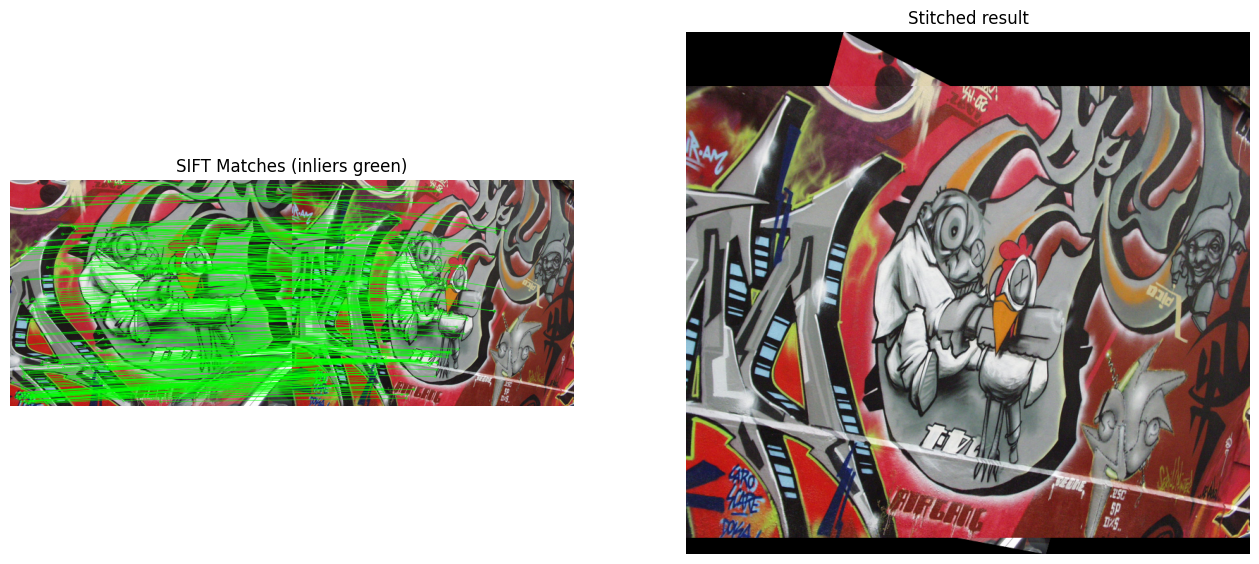

Saved: stitched_result.png


In [1]:
# Q4 - SIFT matching + homography + stitching (Colab cell)
!pip install --quiet opencv-contrib-python matplotlib numpy

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img1 = cv.imread("img1.ppm");
img2 = cv.imread("img3.ppm");

img1_gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
img2_gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

# Create SIFT
sift = cv.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)

# Match descriptors with FLANN
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good = []
for m,n in matches:
    if m.distance < 0.7*n.distance:
        good.append(m)
print("Good matches:", len(good))

if len(good) < 4:
    raise RuntimeError("Not enough matches for homography.")

# Prepare points for RANSAC homography
src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
matches_mask = mask.ravel().tolist()
print("Homography computed. Inliers:", int(np.sum(matches_mask)), "/", len(matches_mask))

# Stitch: warp img1 onto img2 coordinate frame
h1,w1 = img1.shape[:2]
h2,w2 = img2.shape[:2]

# corners of img1 in img2 frame
corners_img1 = np.float32([[0,0],[w1,0],[w1,h1],[0,h1]]).reshape(-1,1,2)
warped_corners = cv.perspectiveTransform(corners_img1, H)
all_corners = np.vstack((warped_corners, np.float32([[0,0],[w2,0],[w2,h2],[0,h2]]).reshape(-1,1,2)))
[xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
[xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)
translation = [-xmin, -ymin]
H_trans = np.array([[1,0,translation[0]],[0,1,translation[1]],[0,0,1]])

# Warp img1 and place img2
stitched = cv.warpPerspective(img1, H_trans.dot(H), (xmax - xmin, ymax - ymin))
stitched[translation[1]:translation[1]+h2, translation[0]:translation[0]+w2] = img2

# Show matches (optional) and stitched
draw_params = dict(matchColor = (0,255,0), singlePointColor = None, matchesMask = matches_mask, flags = 2)
match_vis = cv.drawMatches(img1, kp1, img2, kp2, good, None, **draw_params)

plt.figure(figsize=(16,8))
plt.subplot(1,2,1); plt.title("SIFT Matches (inliers green)"); plt.imshow(cv.cvtColor(match_vis, cv.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(1,2,2); plt.title("Stitched result"); plt.imshow(cv.cvtColor(stitched, cv.COLOR_BGR2RGB)); plt.axis('off')
plt.show()

# Save
cv.imwrite("stitched_result.png", stitched)
print("Saved: stitched_result.png")
